In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.analysis.calculate_metastability_optimize_K import (find_optimal_K,
                                                             plot_K_optimization,
                                                             plot_arr_K_optimization
)

%load_ext autoreload
%autoreload 2 

# Create a new type of weighted connectome (distance matrix)

In [4]:
# Newly constructed connectivity matrix from distance matrix 
# name_data = "distance_matrix_50"
# name_data = "00_connectomes_orig" # 
name_data = "01_consensus_bin_density_10_percent_50"


################################### EITHER: ###################################

if name_data.startswith("distance_matrix"):
    # Load distance matrices and convert to connectomes
    distance_matrix_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/02_distance_matrices/{name_data}.npy"
    distance_matrices = np.load(distance_matrix_path)

    connectomes = []
    for d in distance_matrices:
        A = np.exp(-d / d.max())
        np.fill_diagonal(A, 0)  # No self-connections
        A = (A + A.T) / 2  # Make symmetric
        A = (A - A.min()) / (A.max() - A.min())
        np.fill_diagonal(A, 0)  # No self-connections
        connectomes.append(A)

    connectomes = np.array(connectomes)
    name_data = name_data + "_not_thresholded"


################################### OR: ###################################


if name_data.startswith("01_consensus") or name_data.startswith("00_connectomes"):
    # Load preprocessed connectomes
    data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{name_data}.npy"
    connectomes = np.load(data_path)


In [5]:
# wei: 
# # data_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/00_connectomes_orig.npy"

# dataset_type_name = "01_consensus_bin_density_10_percent_50"

# # bin and thres and sampled to 100 nodes total: 
# data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{dataset_type_name}.npy"
# connectomes = np.load(data_path)

# A = connectomes[0]

# Calculating optimal Ks

In [6]:
save_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/{name_data}_finer_window")
save_path.mkdir(parents=True, exist_ok=True)


ids_to_evaluate = [0, 103, 169, 188, 206]
K_range = np.logspace(2, 4, 41) # -4, 3, 41)
optimal_metric = 'global'

Optimizing K: 100%|██████████| 41/41 [01:49<00:00,  2.67s/it]


Optimization Results:
Metric optimized: global
Optimal K: 450.0000
Value at optimal K: 0.1075
K range tested: [0.0000, 3000.0000]
Number of K values: 41



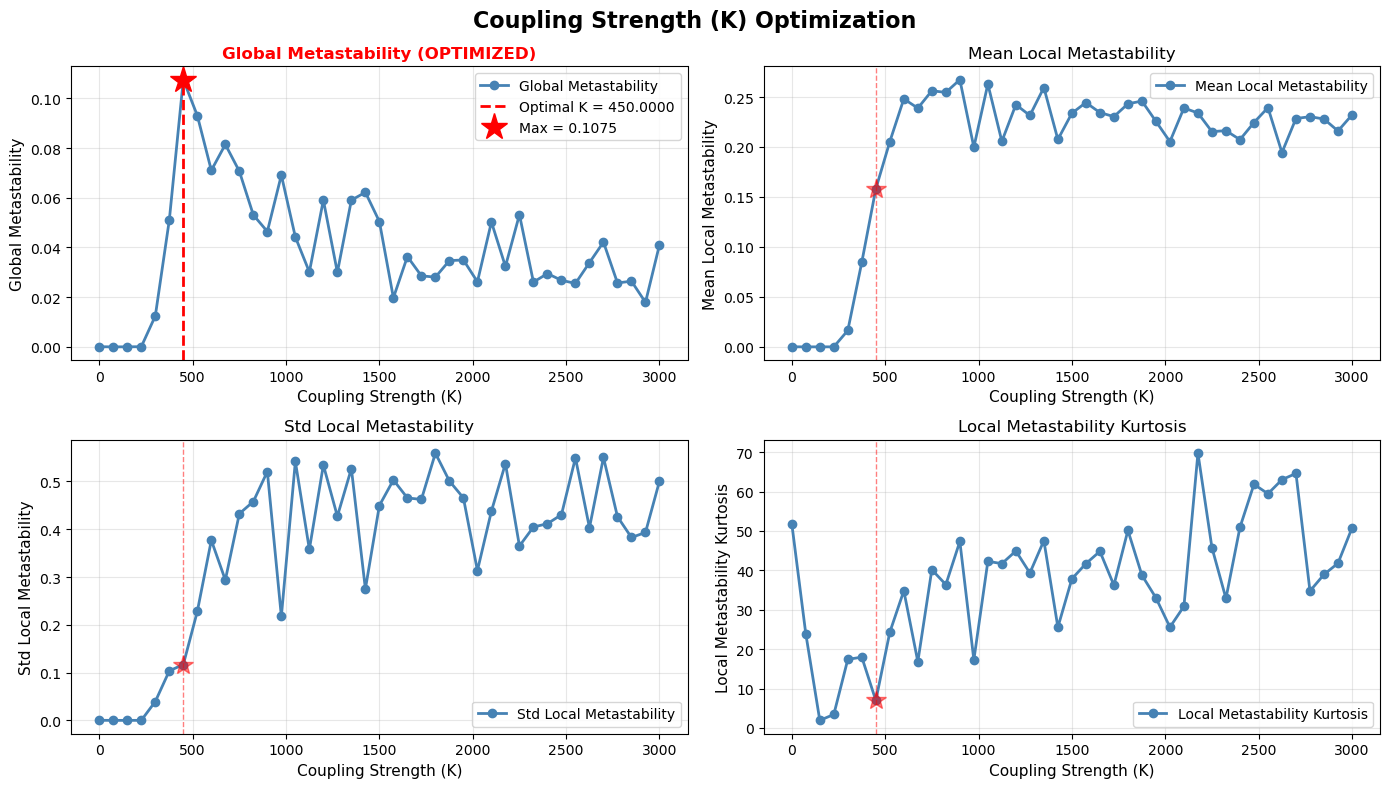

Optimizing K: 100%|██████████| 41/41 [01:52<00:00,  2.75s/it]


Optimization Results:
Metric optimized: global
Optimal K: 525.0000
Value at optimal K: 0.1182
K range tested: [0.0000, 3000.0000]
Number of K values: 41



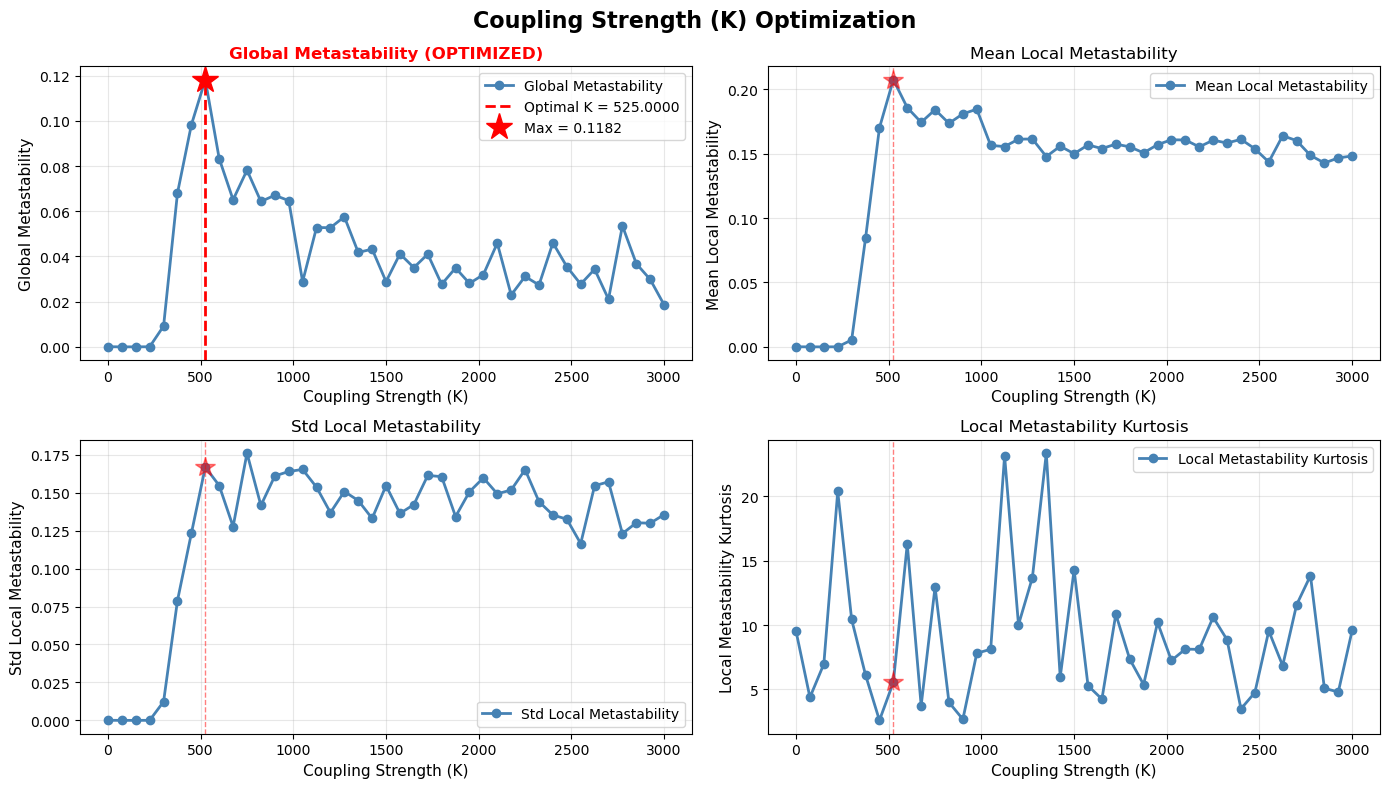

Optimizing K:  22%|██▏       | 9/41 [00:20<01:27,  2.73s/it]

In [ ]:
# bin and thres and sampled to 100 nodes total: 

ids_to_evaluate = [0, 103, 169, 188, 206]
K_range = np.linspace(0, 3000, 41) # np.logspace(-4, 3, 41)
optimal_metric = 'global'


# First get optimal K for each animal, if this is already saved, load it
if (save_path / "K_optimal_arr.npy").exists():
    optimal_K_arr = np.load(save_path / "K_optimal_arr_partial.npy").tolist()
    results_arr = np.load(save_path / "results_arr_partial.npy", allow_pickle=True).tolist()
    start_idx_arr = np.load(save_path / "evaluated_ids_partial.npy").tolist()
else:
    start_idx = 0
    optimal_K_arr = [] 
    results_arr = [] 
    start_idx_arr = []

ids_to_evaluate = set(ids_to_evaluate) - set(start_idx_arr)
ids_to_evaluate = list(ids_to_evaluate)


for animal_id in ids_to_evaluate: 
    A = connectomes[animal_id]

    A = (A + A.T) / 2  # Make symmetric
    np.fill_diagonal(A, 0)  # No self-connections
    A = A / A.sum(axis=1, keepdims=True)  # Normalize

    # Find optimal K
    optimal_K, results = find_optimal_K(
        A, 
        K_range=K_range,
        metric=optimal_metric, 
        sim_time=500,  # Shorter for example
        verbose=True
    )

    # Plot results
    plot_K_optimization(results)
    plt.show()
    
    results = {"optimal_K": optimal_K, 
                "results": results}

    results_arr.append(results)
    optimal_K_arr.append(optimal_K)
    start_idx_arr.append(animal_id)

    # save intermediate results
    np.save(save_path / f"results_arr_partial_animal_id_{animal_id}.npy", results_arr)
    np.save(save_path / f"K_optimal_arr_partial_animal_id_{animal_id}.npy", optimal_K_arr)
    np.save(save_path / f"evaluated_ids_partial_animal_id_{animal_id}.npy", start_idx_arr)

    # break # 2:17  -> 1:03

print(save_path)
# total: 54 min for 5 animals (when 200 total nodes)

In [14]:
results_arr = np.load(save_path / "results_arr_partial.npy", allow_pickle=True)
start_idx_arr = np.load(save_path / "evaluated_ids_partial.npy", allow_pickle=True)

Figure saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/testing/metastability_optimize_K/01_consensus_bin_density_10_percent_50_finer_window/K_optimization_plots_01_consensus_bin_density_10_percent_50.pdf


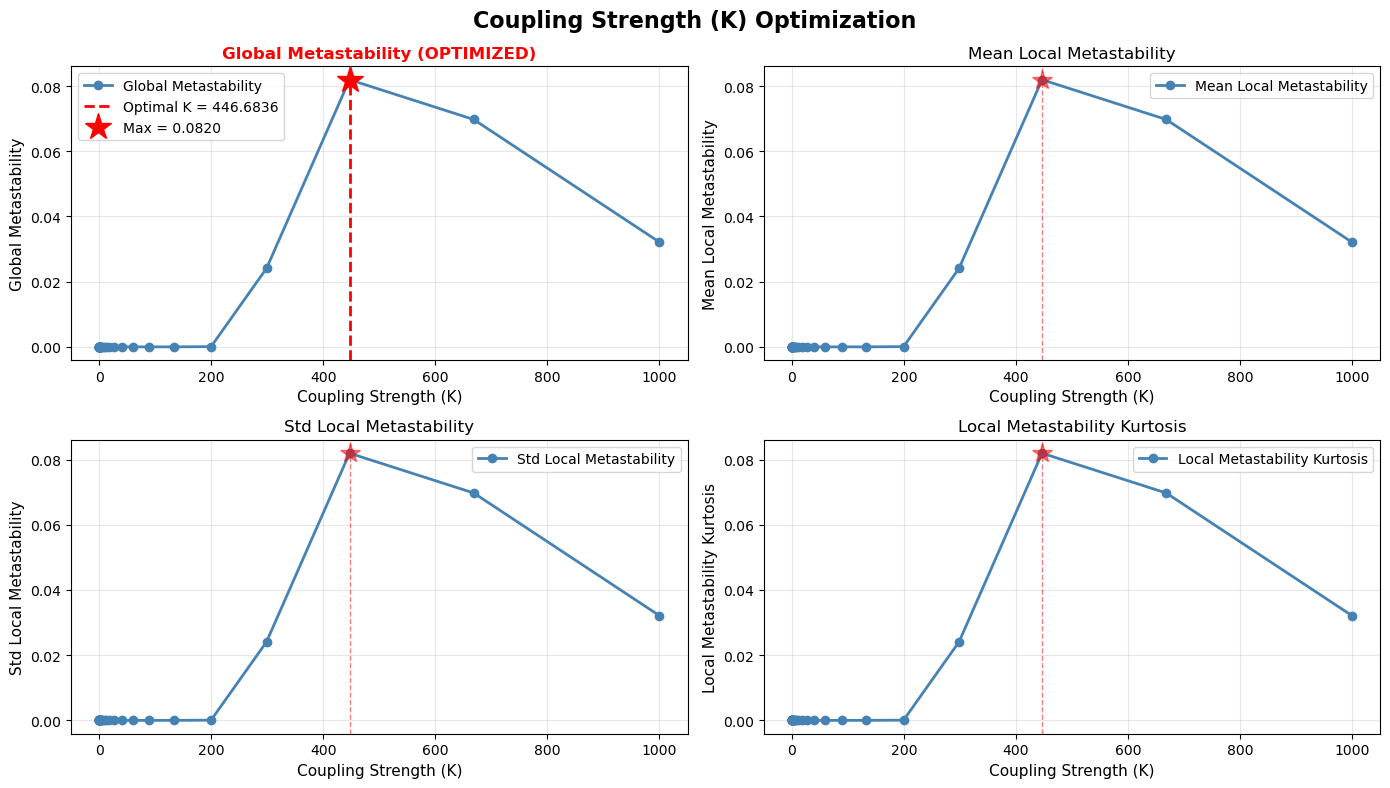

In [15]:
# plot_K_optimization(results)

plot_arr_K_optimization(
    results_arr,
    start_idx_arr,
    optimal_metric, 
    save_path=save_path / f"K_optimization_plots_{name_data}.pdf")

In [26]:
# optimal_K_arr = [] 
# results_arr = [] # Create a random connectivity matrix

# K_vec = np.logspace(-4, 3, 41)
# meta_stabilities = np.zeros(len(K_vec)) # ,212))
# # subset_W = connectomes[::10]
# # subset_W = A
# # meta_global_vec = np.zeros((len(K_vec)))

# # for i, K in enumerate(K_vec):
# #         meta_stabilities[i], _, _ = evaluate_network(W = W, K = K, sim_time = 500)
        
# # Find optimal K
# optimal_K, results = find_optimal_K(
#     A, 
#     K_range=np.logspace(-4, 3, 41), # np.linspace(0.0001, 0.1, 50),
#     metric='global',
#     sim_time=200,  # Shorter for example
#     verbose=True
# )

# # Plot results
# plot_K_optimization(results)

In [27]:
optimal_K

np.float64(668.3439175686135)

In [28]:
results

{'optimal_K': np.float64(668.3439175686135),
 'results': {'K_values': array([1.00000000e-04, 1.49623566e-04, 2.23872114e-04, 3.34965439e-04,
         5.01187234e-04, 7.49894209e-04, 1.12201845e-03, 1.67880402e-03,
         2.51188643e-03, 3.75837404e-03, 5.62341325e-03, 8.41395142e-03,
         1.25892541e-02, 1.88364909e-02, 2.81838293e-02, 4.21696503e-02,
         6.30957344e-02, 9.44060876e-02, 1.41253754e-01, 2.11348904e-01,
         3.16227766e-01, 4.73151259e-01, 7.07945784e-01, 1.05925373e+00,
         1.58489319e+00, 2.37137371e+00, 3.54813389e+00, 5.30884444e+00,
         7.94328235e+00, 1.18850223e+01, 1.77827941e+01, 2.66072506e+01,
         3.98107171e+01, 5.95662144e+01, 8.91250938e+01, 1.33352143e+02,
         1.99526231e+02, 2.98538262e+02, 4.46683592e+02, 6.68343918e+02,
         1.00000000e+03]),
  'global': array([7.79973013e-05, 6.34838043e-05, 5.53418937e-05, 6.57867106e-05,
         6.34085002e-05, 7.76054706e-05, 6.59377820e-05, 6.00542814e-05,
         6.67204201

In [29]:
# # bin and thres and sampled to 100 nodes total: 

# all_results = {}
# dataset_type = "01_consensus_bin_density_10_percent_50" # 01_connectomes_orig, bin_density_10_percent_50

# for animal_id in [0, 103, 169, 188, 206]:  # You can add more animal IDs here
#     data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{dataset_type}.npy"
#      # Load connectivity matrix
#     A = np.load(data_path)[0]

#     # Create a random connectivity matrix
#     A = (A + A.T) / 2  # Make symmetric
#     np.fill_diagonal(A, 0)  # No self-connections
#     A = A / A.sum(axis=1, keepdims=True)  # Normalize

#     # Find optimal K
#     optimal_K, results = find_optimal_K(
#         A, 
#         K_range=np.linspace(0.0001, 0.1, 50),
#         metric='global',
#         sim_time=2000,  # Shorter for example
#         verbose=True
#     )

#     # Plot results
#     plot_K_optimization(results)
#     plt.show()
    
#     results = {"optimal_K": optimal_K, 
#                 "results": results}

#     all_results.update({"data_id_{}".format(animal_id): results})

#     # save intermediate results
#     np.save(save_path / "optimize_K_results_partial.npy", all_results)
    
#     break # 5 min, 15s 

In [30]:
# # bin and thres and sampled to 100 nodes total: 

# all_results = {}
# dataset_type = "00_connectomes_orig" # 01_consensus_bin_density_10_percent_50" # 00_connectomes_orig, bin_density_10_percent_50

# for animal_id in [0, 103, 169, 188, 206]:  # You can add more animal IDs here
#     data_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/suarez_MaMI_dataset/01_connectomes/{dataset_type}.npy"
#      # Load connectivity matrix
#     A = np.load(data_path)[0]

#     # Create a random connectivity matrix
#     A = (A + A.T) / 2  # Make symmetric
#     np.fill_diagonal(A, 0)  # No self-connections
#     A = A / A.sum(axis=1, keepdims=True)  # Normalize

#     # Find optimal K
#     optimal_K, results = find_optimal_K(
#         A, 
#         K_range=np.linspace(0.0001, 0.1, 50),
#         metric='global',
#         sim_time=2000,  # Shorter for example
#         verbose=True
#     )

#     # Plot results
#     plot_K_optimization(results)
#     plt.show()
    
#     results = {"optimal_K": optimal_K, 
#                 "results": results}

#     all_results.update({"data_id_{}".format(animal_id): results})

#     # save intermediate results
#     np.save(save_path / "optimize_K_results_partial.npy", all_results)
    
#     break # 